## Assumptions of Linear Regression

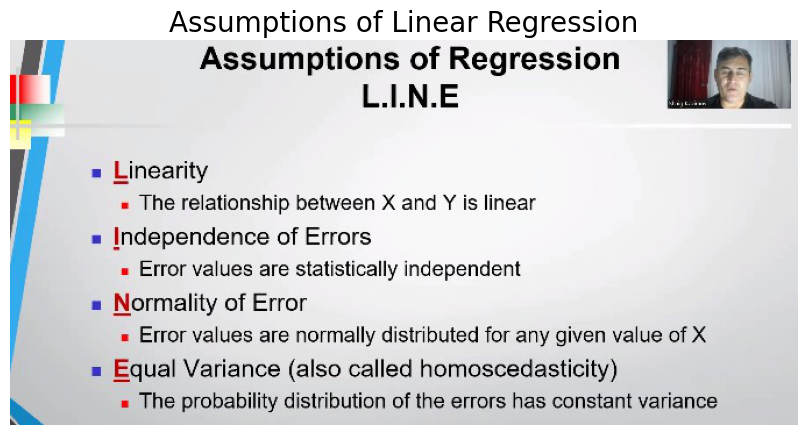

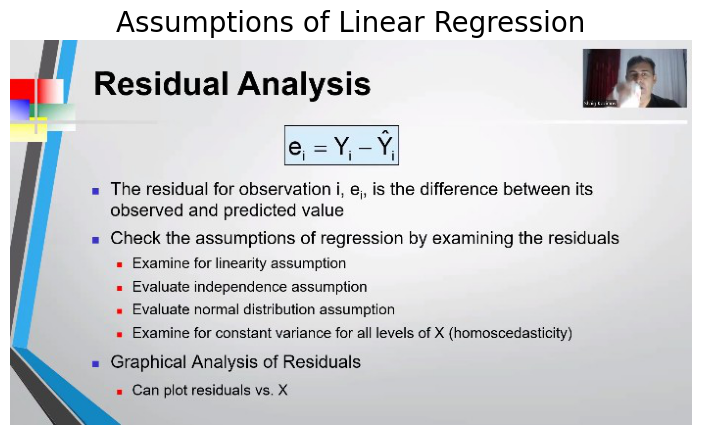

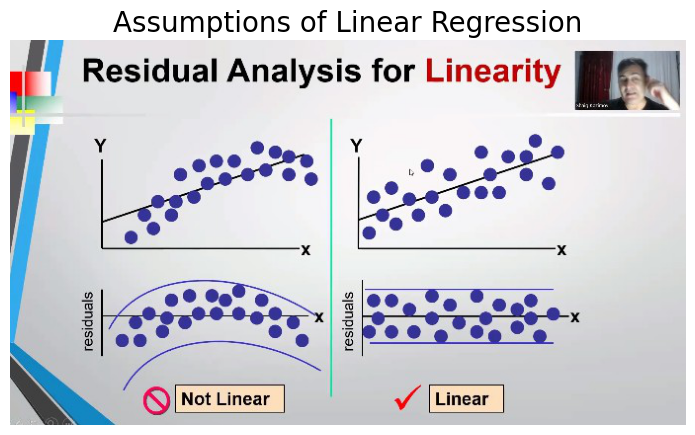

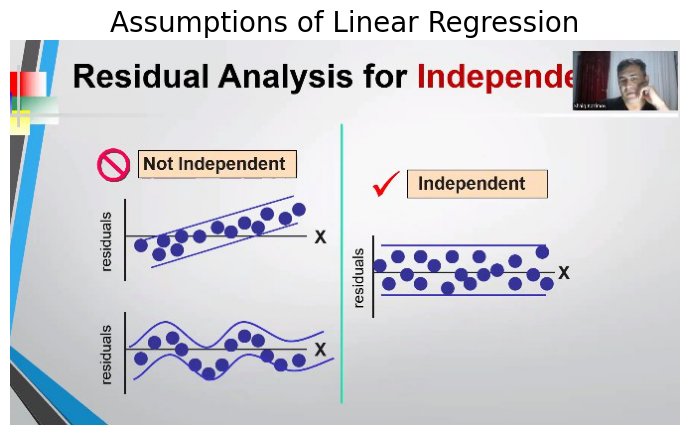

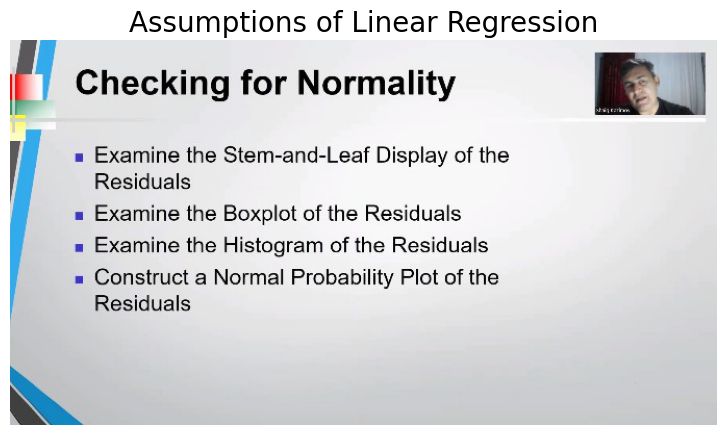

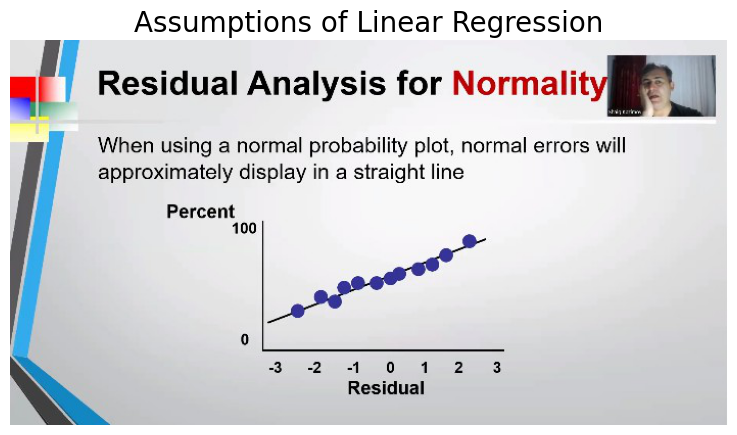

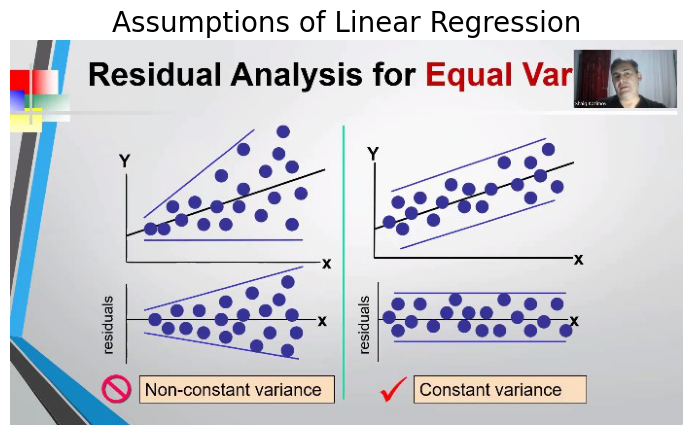

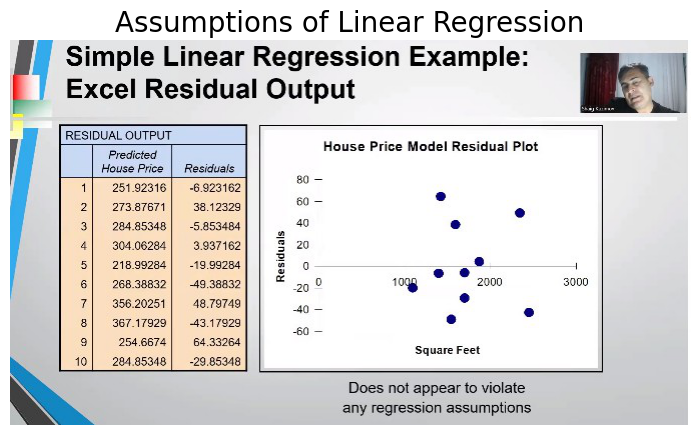

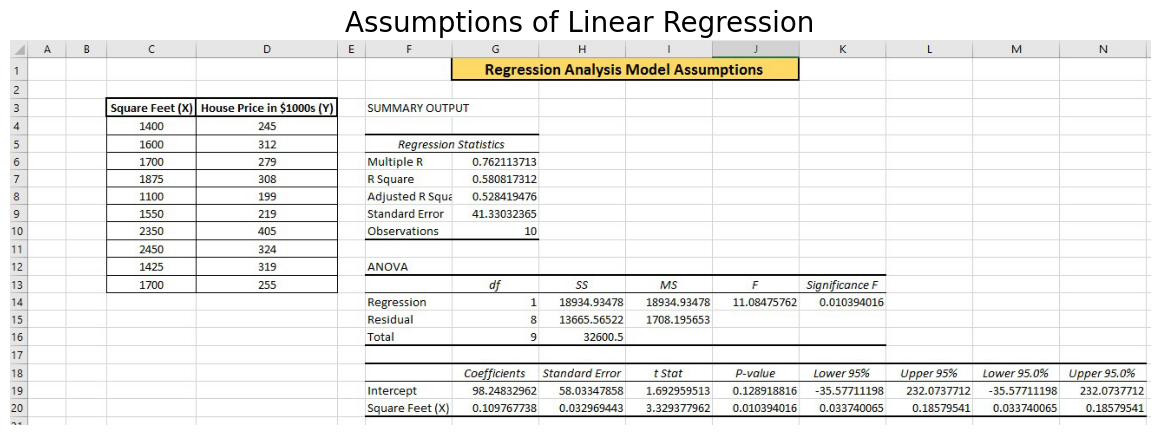

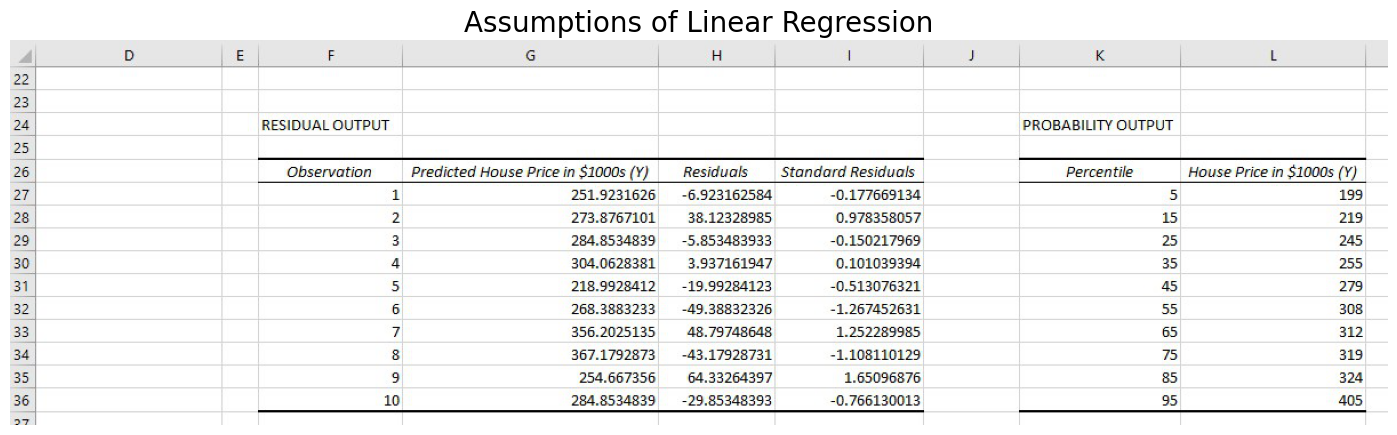

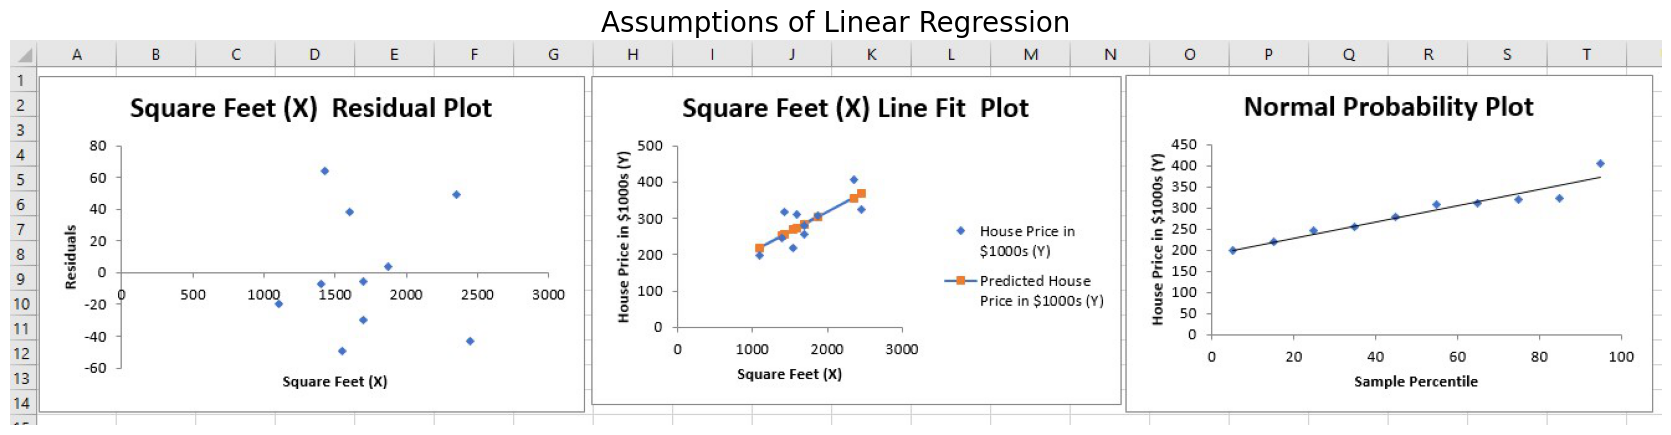

In [3]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Excel\Handex Excel\Statistics\Season_2\Telim_13\Pictures\Distribution_6_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 12):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for image in image_list:
    plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü
    plt.title("Assumptions of Linear Regression", size=20)
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

## Assumptions of Linear Regression

In [2]:
import pandas as pd
from sklearn.datasets import load_diabetes

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


## 1). Linearity General Check

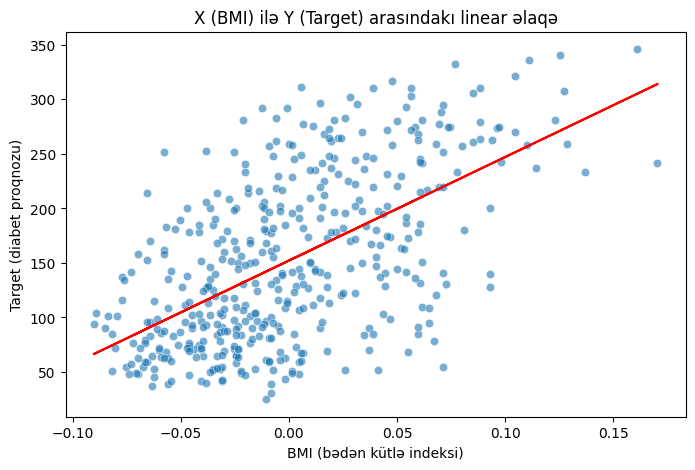

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Sadəlik üçün bir X sütunu seçək (məsələn, 'bmi') və target
X = df[["bmi"]]
y = df["target"]

# Linear regresiya modeli quraq
model = LinearRegression()
model.fit(X, y)

# Fitted (proqnoz edilən) dəyərlər
y_pred = model.predict(X)

# Scatter plot + regresiya xətti
plt.figure(figsize=(8,5))
sns.scatterplot(x=X["bmi"], y=y, alpha=0.6)
plt.plot(X, y_pred, color="red")  # regresiya xətti
plt.xlabel("BMI (bədən kütlə indeksi)")
plt.ylabel("Target (diabet proqnozu)")
plt.title("X (BMI) ilə Y (Target) arasındakı linear əlaqə")
plt.show()

## 2). Linearity Check



### ✅ Əgər linearlıq fərziyyəsi düzgünsə:

* Qalıqlar (residuals) **0 ətrafında təsadüfi şəkildə dağılmalıdır**.
* Heç bir **sistematik naxış** (pattern) olmamalıdır.
* Plotda sanki “bulud” kimi görünür, **nə trend, nə də forma yoxdur**.

---

### ❌ Əgər linearlıq fərziyyəsi pozulubsa:

1. **Qalıqlarda trend**

   * Qalıqlar artan və ya azalan şəkildə sıralanırsa → model linearlığı düzgün tutmayıb.
   * Yəni daha yaxşı model (məs. polynomial regression) lazım ola bilər.

2. **Qalıqlarda əyri (U-şəkilli, parabola)**

   * Demək ki, asılılıq kvadrat və ya başqa qeyri-xətti forma daşıyır.
   * Sadə lineer model düzgün deyil.
   

#### Məntiq

Linear regression-in əsas fərziyyəsi budur ki:

$$
y = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n + \varepsilon
$$

və burada **qalıqlar (residuals)** sadəcə təsadüfi səhv olmalıdır:

$$
\varepsilon_i = y_i - \hat{y}_i
$$

Əgər model doğrudan da **x və y arasında linearlığı** düzgün tutubsa, onda qalıqlar:

* **0 ətrafında təsadüfi paylanmalıdır (heç bir naxış olmamalıdır).**
* **X dəyişənlərindən asılı olmamalıdır.**


####  Niyə residual vs X plot edilir?

Çünki əgər **linearlıq fərziyyəsi pozulubsa**, onda:

* Qalıqlar X-ə qarşı sistematik naxış göstərəcək (məs: parabola, U-forma, artan/azalan trend).
* Bu da deməkdir ki, modelin linearlıq fərziyyəsi səhvdir, başqa transformasiya və ya polynomial regression lazım ola bilər.


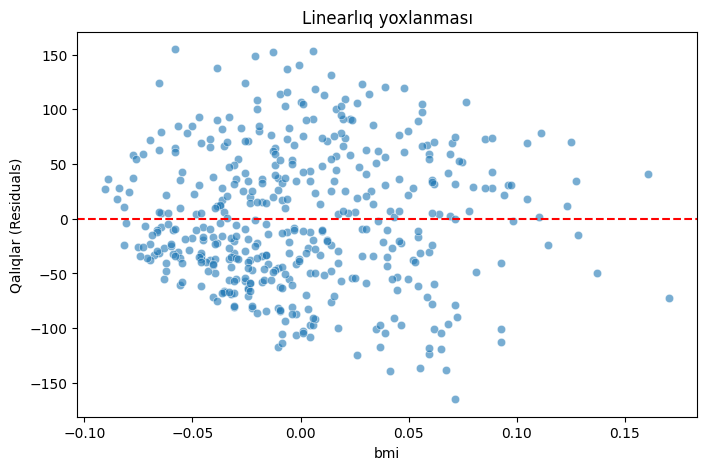

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Sadəlik üçün bir X sütunu seçək (məsələn, 'bmi') və target
X = df[["bmi"]]
y = df["target"]

# Linear regresiya modeli
model = LinearRegression()
model.fit(X, y)

# Proqnozlar və qalıqlar
y_pred = model.predict(X)
residuals = y - y_pred

# Linearlıq yoxlanması (Residuals vs X)
plt.figure(figsize=(8,5))
sns.scatterplot(x=X["bmi"], y=residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("bmi")
plt.ylabel("Qalıqlar (Residuals)")
plt.title("Linearlıq yoxlanması")
plt.show()

## 3). Homoscedasticity Check

**Heteroskedastiklik (sistematik yayılma)**

   * Qalıqlar fitted values artdıqca “fan” və ya “konus” kimi açılırsa → dispersiya sabit deyil.
   * Bu halda **Homoskedasticity** fərziyyəsi pozulur.


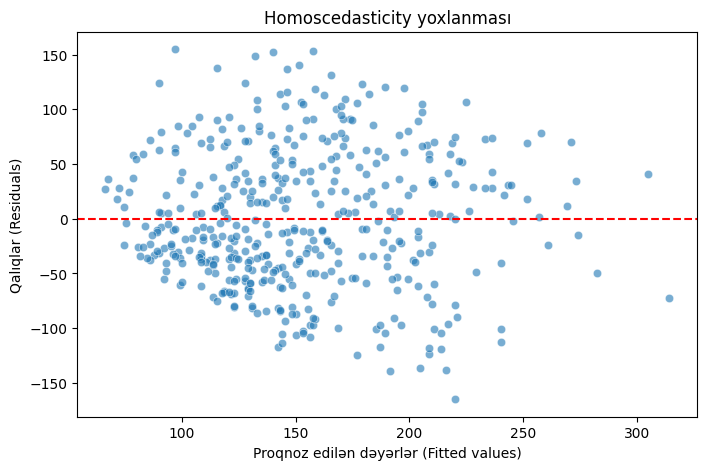

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Sadəlik üçün bir X sütunu seçək (məsələn, 'bmi') və target
X = df[["bmi"]]
y = df["target"]

# Linear regresiya modeli
model = LinearRegression()
model.fit(X, y)

# Proqnozlar və qalıqlar
y_pred = model.predict(X)
residuals = y - y_pred

# Homoscedasticity yoxlamaq üçün plot
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Proqnoz edilən dəyərlər (Fitted values)")
plt.ylabel("Qalıqlar (Residuals)")
plt.title("Homoscedasticity yoxlanması")
plt.show()


## 4).Normality

### 1) Vizual yoxlama – Histogram + Q-Q Plot


### Q-Q plot-un işləmə prinsipi – addım-addım

1. **Data sıralanır**
   Sənin residuals və ya istənilən data vektoru olsun:

   ```
   x = [2.1, -0.5, 1.2, 0.3, 1.8]
   ```

   Əvvəl **artan sıraya düzürük**:

   ```
   x_sorted = [-0.5, 0.3, 1.2, 1.8, 2.1]
   ```

   Bu artan sıra → **order statistics**.

---

2. **Plotting position (i/n) hesablanır**
   Hər bir sıradakı nöqtəyə uyğun nəzərdə tutulan paylanmanın quantile-i tapılır.

   Formula:

   $$
   p_i = \frac{i - 0.5}{n}
   $$

   Burada:

   * $i$ → sıralamadakı nöqtə (1-dən n-ə qədər)
   * $n$ → data ölçüsü

   Məsələn, 5 dəyər üçün:

   ```
   i=1 → p1 = (1-0.5)/5 = 0.1
   i=2 → p2 = (2-0.5)/5 = 0.3
   i=3 → p3 = 0.5
   i=4 → p4 = 0.7
   i=5 → p5 = 0.9
   ```

---

3. **Nəzərdə tutulan paylanmanın quantile-ləri tapılır**
   Məsələn, normal paylanma üçün:

   $$
   q_i = F^{-1}(p_i)
   $$

   Burada $F^{-1}$ → normal paylanmanın **invers CDF** (z-score).

   Yəni p1 = 0.1 → q1 ≈ -1.28, p2 = 0.3 → q2 ≈ -0.52 və s.

---

4. **Q-Q plot-u çəkirik**

   * **X oxu** → nəzərdə tutulan paylanmanın quantile-ləri $q_i$
   * **Y oxu** → sənin data quantile-lərin $x_{(i)}$

   ```
   Plot points: (q1, x_sorted[0]), (q2, x_sorted[1]), ...
   ```

5. **Nəticəni yoxlamaq**

   * Nöqtələr **xətt üzrə düzdür** → data normal paylanır
   * Nöqtələr xəttdən sapır → normality pozulub




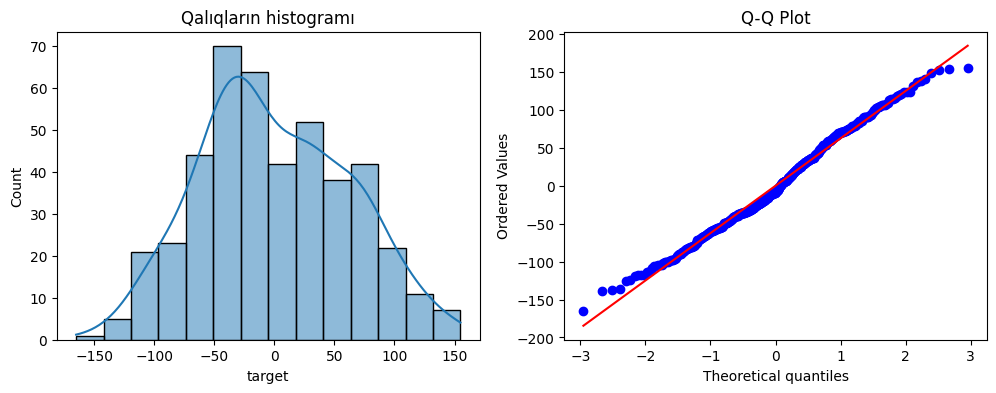

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Sadəlik üçün bir X sütunu seçək (məsələn, 'bmi') və target
X = df[["bmi"]]
y = df["target"]

# Linear regresiya modeli
model = LinearRegression()
model.fit(X, y)

# Proqnozlar və qalıqlar
y_pred = model.predict(X)
residuals = y - y_pred

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Histogram
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Qalıqların histogramı")

# Q-Q Plot
plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

### 2).Statistik test – Shapiro-Wilk testi

In [7]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)
print("Shapiro-Wilk testi p-value:", p)

if p > 0.05:
    print("Qalıqlar normal paylanmışdır (H0 qəbul edilir)")
else:
    print("Qalıqlar normal paylanmamışdır (H0 rədd edilir)")

Shapiro-Wilk testi p-value: 0.00542087725922064
Qalıqlar normal paylanmamışdır (H0 rədd edilir)


### 3).Kolmogorov-Smirnov (K-S) testi

In [8]:
from scipy.stats import kstest, norm
import numpy as np

# Qalıqları standartlaşdırmaq (mean=0, std=1)
residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)

# K-S testi
stat, p = kstest(residuals_std, 'norm')
print("Kolmogorov-Smirnov testi p-value:", p)

if p > 0.05:
    print("Qalıqlar normal paylanmışdır (H0 qəbul edilir)")
else:
    print("Qalıqlar normal paylanmamışdır (H0 rədd edilir)")


Kolmogorov-Smirnov testi p-value: 0.10573962306836016
Qalıqlar normal paylanmışdır (H0 qəbul edilir)


## 5).Qalıqların Sum ve Mean Sıfıra Bərabər Olması

### Qalıqların (residuals) **sum və mean-inin sıfır olmasının səbəbi**

1. Linear regression modelində:

$$
y_i = \hat{y}_i + e_i
$$

* $y_i$ → real dəyər
* $\hat{y}_i$ → modelin proqnozu
* $e_i = y_i - \hat{y}_i$ → residual (qalığı)

---

2. **OLS (Ordinary Least Squares) metodu** minimallaşdırır:

$$
\text{SSE} = \sum_{i=1}^n e_i^2
$$

* Əmsalları seçərkən **qalığın cəmini sıfıra yaxınlaşdırır**, çünki bu **minimum squared error** üçün optimal şərtdir.

---

3. Riyazi baxımdan:

$$
\sum_{i=1}^n e_i = \sum_{i=1}^n (y_i - \hat{y}_i) = 0
$$

və buna görə:

$$
\bar{e} = \frac{1}{n} \sum_{i=1}^n e_i = 0
$$

* Yəni **qalığın ortalaması da sıfır olur**.

---

4. **Praktik səbəb:**

* Linear regression xətti **data-nın mərkəzindən keçir** → proqnozlar real dəyərlərin ortalama xəttinə uyğun olur.
* Bu səbəbdən qalıqların sum və mean-i **təbiətən sıfırdır**.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Sadəlik üçün bir X sütunu seçək (məsələn, 'bmi') və target
X = df[["bmi"]]
y = df["target"]


import numpy as np
import statsmodels.api as sm

X_sm = sm.add_constant(X)  # intercept əlavə olunur
model_sm = sm.OLS(y, X_sm).fit()
residuals = model_sm.resid

print(f"Residuals sum: {np.sum(residuals):.5f}")
print(f"Residuals mean: {np.mean(residuals):.5F}")

Residuals sum: 0.00000
Residuals mean: 0.00000


## 6). Autocorrelation & Multicollinearity


### 1️) Autocorrelation (qalıqların ardıcıl bağlılığı)

### a) Durbin-Watson testi

* **H0:** Qalıqlar arasında autocorrelation yoxdur
* **d-value**:

  * $≈$2 → autocorrelation yoxdur
  * $<$2 → positive autocorrelation
  * $>$2 → negative autocorrelation

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Sadəlik üçün bir X sütunu seçək (məsələn, 'bmi') və target
X = df[["bmi"]]
y = df["target"]


from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Model üçün statsmodels istifadə
X_sm = sm.add_constant(X)  # intercept əlavə olunur
model_sm = sm.OLS(y, X_sm).fit()
residuals = model_sm.resid

dw_stat = durbin_watson(residuals)
print("Durbin-Watson stat:", dw_stat)

Durbin-Watson stat: 1.8481670238115966


### b) Autocorrelation plot (vizual)

* Əgər nöqtələr təsadüfi səpələnibsə → autocorrelation yoxdur.
* Pattern varsa → autocorrelation mövcuddur.

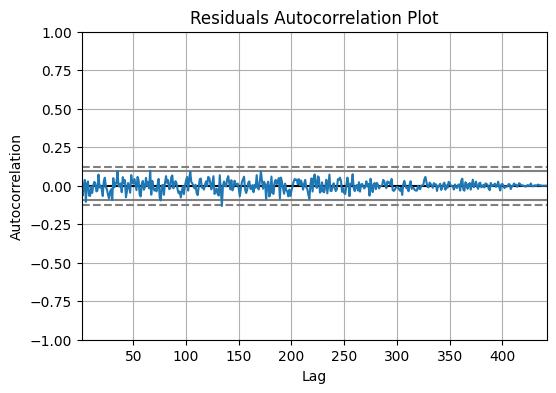

In [11]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
autocorrelation_plot(residuals)
plt.title("Residuals Autocorrelation Plot")
plt.show()

### C) ACF (Autocorrelation Function) plot

* X-oxu → lag (qalıqların ardıcıl məsafəsi)
* Y-oxu → autocorrelation dəyəri
* **Mavi xətlərin xaricindəki dəyərlər** statistik olaraq əhəmiyyətli autocorrelation-u göstərir.

<Figure size 800x400 with 0 Axes>

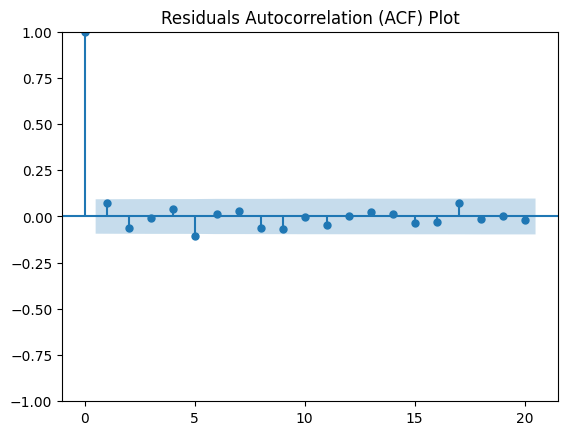

In [12]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

# Model qurmaq (statsmodels ilə)
X_sm = sm.add_constant(X)  # intercept əlavə olunur
model_sm = sm.OLS(y, X_sm).fit()
residuals = model_sm.resid

# ACF plot
plt.figure(figsize=(8,4))
plot_acf(residuals, lags=20)
plt.title("Residuals Autocorrelation (ACF) Plot")
plt.show()

## 2). Multicollinearity (X dəyişənləri arasında çoxsətirlilik)

* **VIF (Variance Inflation Factor)** istifadə olunur
* VIF > 5–10 → ciddi multicollinearity

* Burada hər bir feature üçün VIF hesablanır.
* Əgər çox yüksəkdirsə → o feature digər X-lərlə çox korrelyasiyalıdır.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Sadəlik üçün bir X sütunu seçək (məsələn, 'bmi') və target
X = df[["bmi"]]
y = df["target"]


from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Bütün X-ləri daxil edək
X_all = df[data.feature_names]

vif_data = pd.DataFrame()
vif_data["feature"] = X_all.columns
vif_data["VIF"] = [variance_inflation_factor(X_all.values, i) for i in range(X_all.shape[1])]
print(vif_data)

  feature        VIF
0     age   1.217307
1     sex   1.278071
2     bmi   1.509437
3      bp   1.459428
4      s1  59.202510
5      s2  39.193370
6      s3  15.402156
7      s4   8.890986
8      s5  10.075967
9      s6   1.484623


## Summary

### Summary-də nə görəcəksən:

* **R-squared** → modelin izah etdiyi variance faizi
* **Adj. R-squared** → R²-in adjusted versiyası
* **coef** → hər bir X üçün əmsallar (β0 = intercept, β1 = bmi)
* **std err** → əmsalın standart xətası
* **t** və **P>|t|** → əmsalın statistik əhəmiyyətini göstərir
* **Omnibus, Prob(Omnibus), Jarque-Bera** → residuals-un normality testləri
* **Durbin-Watson** → residuals-un autocorrelation testi



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

# Dataseti yükləyək
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# X və y seçək
X = df[['bmi']]          # nümunə üçün BMI istifadə edirik
y = df['target']         # target sütunu


import statsmodels.api as sm

# Intercept əlavə edirik
X_sm = sm.add_constant(X)

# OLS modelini qururuq
model = sm.OLS(y, X_sm).fit()

# Nəticələri çap edirik
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     230.7
Date:                Mon, 01 Sep 2025   Prob (F-statistic):           3.47e-42
Time:                        18:06:50   Log-Likelihood:                -2454.0
No. Observations:                 442   AIC:                             4912.
Df Residuals:                     440   BIC:                             4920.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.974     51.162      0.0